In [1]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import PyComplexHeatmap as pch
import matplotlib.pyplot as plt
from collections import defaultdict
from upsetplot import UpSet, from_indicators


# Fig. S4a

In [2]:
deg_df = pd.read_csv('/share/crsp/lab/seyedam/share/igvf_pipeline/figures/specificity/sig_degs_all_tissues_tissue_level.csv', index_col = 0)


In [3]:
import pandas as pd

# Clean 'comparison' column by stripping 'Genotype_'
deg_df["comparison_clean"] = deg_df["comparison"].str.replace("^Genotype_", "", regex=True)

# Flip comparisons if LFC < 0 so that 'adjusted_comparison' always means:
# "upregulated genotype vs downregulated genotype"
deg_df["upregulated_comparison"] = deg_df.apply(
    lambda row: row["comparison_clean"] 
    if row["log2FoldChange"] > 0 
    else "_vs_".join(reversed(row["comparison_clean"].split("_vs_"))),
    axis=1
)

# Count number of unique DE genes per tissue and adjusted comparison
df_pivot = (
    deg_df.groupby(["tissue", "upregulated_comparison"])["gene_name"]
    .nunique()
    .unstack(fill_value=0)
)


In [4]:
# Extract all unique comparisons in "A_vs_B" format
all_comparisons = sorted(df_pivot.columns)

# Or define your own preferred order:
comparison_order = [
    f"{g1}_vs_{g2}"
    for g1 in ['AJ', 'B6J', '129S1J', 'NODJ', 'NZOJ', 'CASTJ', 'PWKJ', 'WSBJ']
    for g2 in ['AJ', 'B6J', '129S1J', 'NODJ', 'NZOJ', 'CASTJ', 'PWKJ', 'WSBJ']
    if g1 != g2
]

# Only keep those comparisons that exist in the data
comparison_order = [c for c in comparison_order if c in df_pivot.columns]

# Reorder columns
df_pivot = df_pivot[comparison_order]


In [5]:
comparison_order = [
    'AJ_vs_B6J', 'AJ_vs_129S1J', 'AJ_vs_NODJ', 'AJ_vs_NZOJ','AJ_vs_CASTJ', 'AJ_vs_PWKJ', 'AJ_vs_WSBJ', 
    'B6J_vs_AJ','B6J_vs_129S1J', 'B6J_vs_NODJ', 'B6J_vs_NZOJ', 'B6J_vs_CASTJ', 'B6J_vs_PWKJ', 'B6J_vs_WSBJ', 
    '129S1J_vs_AJ','129S1J_vs_B6J', '129S1J_vs_NODJ', '129S1J_vs_NZOJ', '129S1J_vs_CASTJ', '129S1J_vs_PWKJ', '129S1J_vs_WSBJ', 
    'NODJ_vs_AJ','NODJ_vs_B6J', 'NODJ_vs_129S1J', 'NODJ_vs_NZOJ', 'NODJ_vs_CASTJ', 'NODJ_vs_PWKJ', 'NODJ_vs_WSBJ',
    'NZOJ_vs_AJ', 'NZOJ_vs_B6J', 'NZOJ_vs_129S1J', 'NZOJ_vs_NODJ',  'NZOJ_vs_CASTJ', 'NZOJ_vs_PWKJ','NZOJ_vs_WSBJ', 
    'CASTJ_vs_AJ','CASTJ_vs_B6J', 'CASTJ_vs_129S1J', 'CASTJ_vs_NODJ', 'CASTJ_vs_NZOJ', 'CASTJ_vs_PWKJ','CASTJ_vs_WSBJ', 
    'PWKJ_vs_AJ', 'PWKJ_vs_B6J', 'PWKJ_vs_129S1J', 'PWKJ_vs_NODJ', 'PWKJ_vs_NZOJ',  'PWKJ_vs_CASTJ', 'PWKJ_vs_WSBJ',
    'WSBJ_vs_AJ', 'WSBJ_vs_B6J', 'WSBJ_vs_129S1J', 'WSBJ_vs_NODJ', 'WSBJ_vs_NZOJ',  'WSBJ_vs_CASTJ', 'WSBJ_vs_PWKJ',

]

In [6]:
df_pivot_reordered = df_pivot[comparison_order]
desired_order = [
    "CortexHippocampus", 
    "DiencephalonPituitary", 
    "Heart",
    "GonadsFemale",     
    "Adrenal", 
    "Gastrocnemius", 
    "Kidney", 
    "Liver", 
    "GonadsMale", 
    
]

# Ensure the index is in the desired order
df_pivot_reordered.index = pd.Categorical(df_pivot_reordered.index, 
                                          categories=desired_order, 
                                          ordered=True)

# Sort the DataFrame by the new categorical index
df_pivot_reordered = df_pivot_reordered.sort_index()


In [7]:
column_names = df_pivot.columns

geno_dict = {
    '129S1J': '#DA9CC1',  
    'AJ': '#F4C245',             
    'B6J': '#C0BFBF',               
    'CASTJ': '#55AF5B',  
    'NODJ': '#4F6EAF',        
    'NZOJ': '#52A5DB',              
    'PWKJ': '#D83026',        
    'WSBJ': '#683C91'   
}


# Initialize lists to store genotype information
genotype1 = []
genotype2 = []

# Extract genotypes from the column names
for col in column_names:
    g1, g2 = col.split('_vs_')
    genotype1.append(g1)
    genotype2.append(g2)

# Create the supporting DataFrame df_col
df_col = pd.DataFrame({
    'Genotype1': genotype1,
    'Genotype2': genotype2
}, index=column_names)


wild_strains = ['WSBJ', 'CASTJ', 'PWKJ']

# Create the 'Strain_type' column based on Genotype1 and Genotype2
df_col['Strain_type'] = df_col.apply(
    lambda row: 'Wild' if row['Genotype1'] in wild_strains or row['Genotype2'] in wild_strains else 'Lab', 
    axis=1
)


col_ha = pch.HeatmapAnnotation(Genotype1=pch.anno_simple(df_col['Genotype1'],colors=geno_dict),
                               Genotype2=pch.anno_simple(df_col['Genotype2'],colors=geno_dict),
                               #Strain_type=pch.anno_simple(df_col['Strain_type'],colors=strain_dict),
                               verbose=1,axis=1,
                               label_kws = {'visible': False},
                              )
comparison_order_reversed = comparison_order[::-1]


Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 23.6375 mm


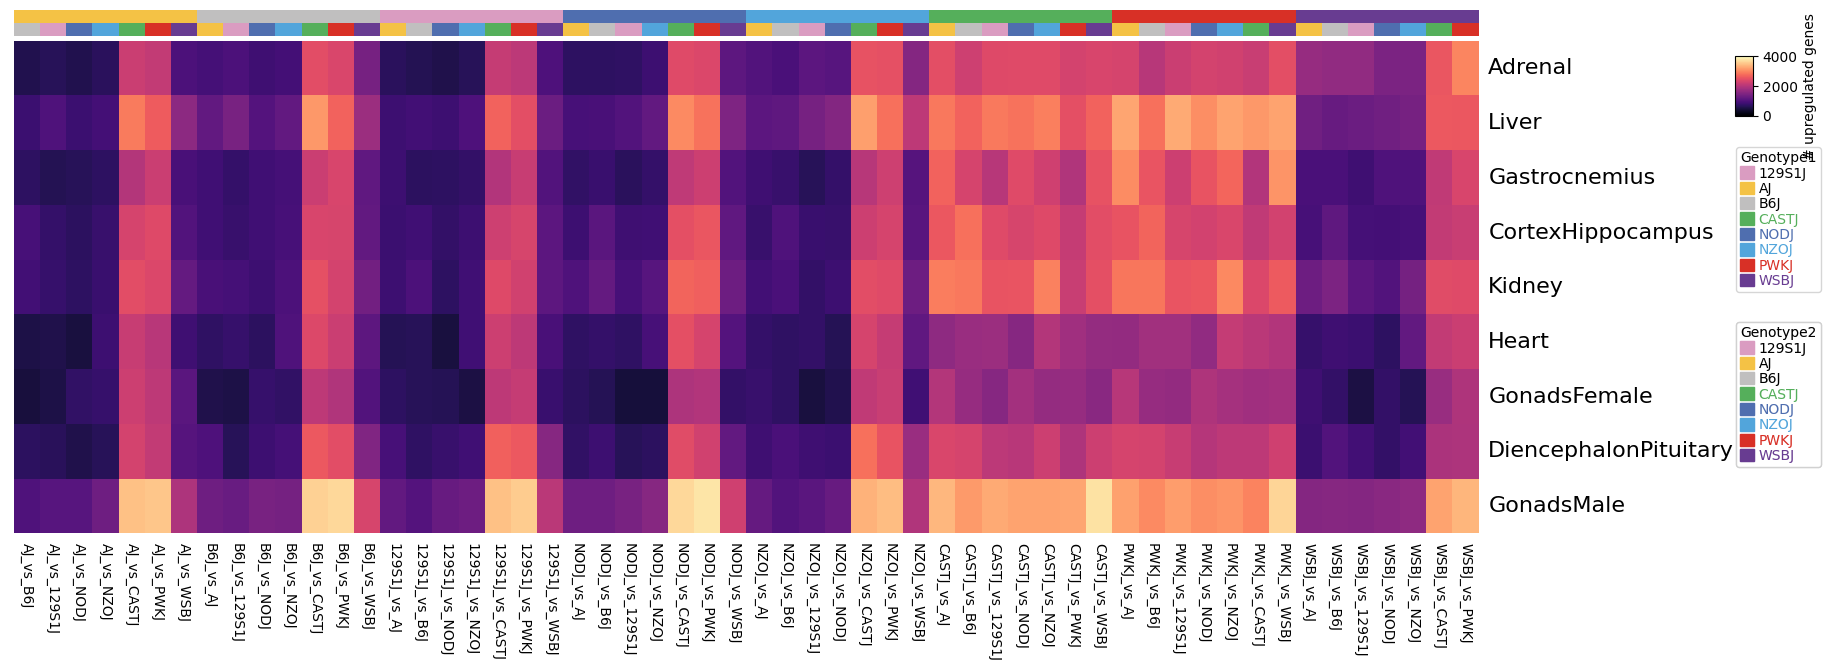

In [9]:
plt.figure(figsize=(19, 6))
cm = pch.ClusterMapPlotter(data=df_pivot_reordered,
                           show_rownames = True, 
                           show_colnames = True, 
                           cmap = "magma",
                           label = "# upregulated genes",
                           top_annotation=col_ha, 
                           yticklabels_kws={'labelsize': 16},
                           row_cluster=True,
                           col_cluster=False,
                           vmin=0, 
                           vmax=4000
                          )

plt.savefig("../supp_fig4/geno_specific_gene_hmap_all_tissues_pbulk_sample_tissue_level.png",bbox_inches='tight',dpi=300)
plt.show()



# Fig. S4b

In [2]:
geno_degs = pd.read_csv('/share/crsp/lab/seyedam/share/igvf_pipeline/figures/specificity/sig_degs_all_tissues_b6j_tissue_level.csv', index_col = 0)

geno_degs_my_geno = geno_degs

merged_df_filt_degs = geno_degs_my_geno[['gene_name', 'tissue']].drop_duplicates()

tissue_gene_sets = defaultdict(set)
for _, row in merged_df_filt_degs.iterrows():
    tissue_gene_sets[row['tissue']].add(row['gene_name'])

    
all_genes = set(merged_df_filt_degs['gene_name'])
binary_matrix = {tissue: [gene in genes for gene in all_genes] for tissue, genes in tissue_gene_sets.items()}
upset_df = pd.DataFrame(binary_matrix, index=list(all_genes))



In [8]:
upset_df.to_csv('../supp_fig4/upset_df.csv')

/home/jovyan/.local/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/jovyan/.local/lib/python3.10/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

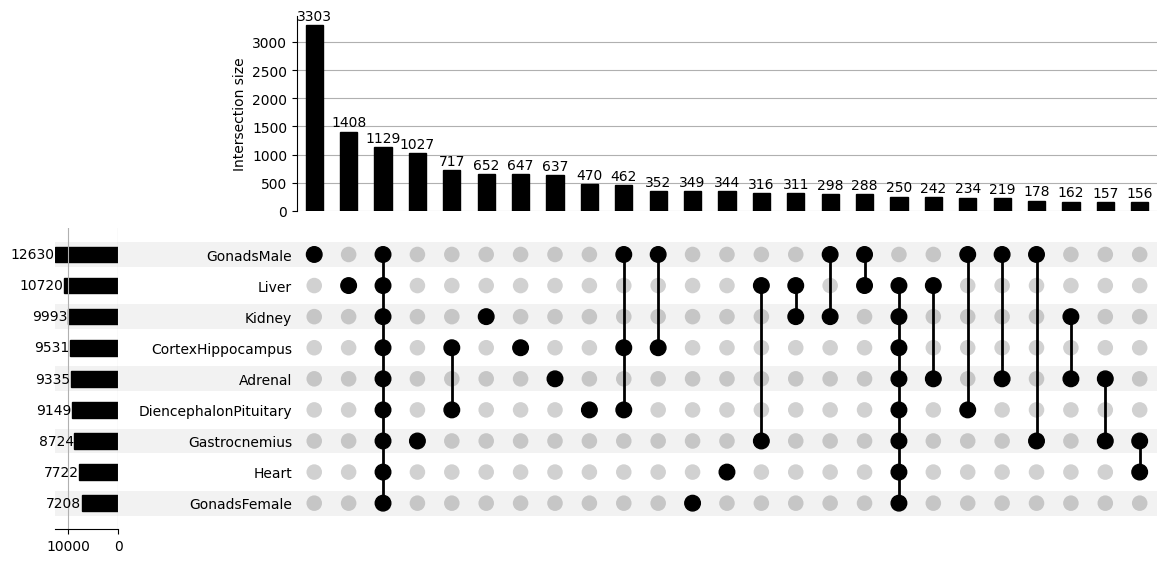

In [5]:
from upsetplot import UpSet, from_indicators
import matplotlib.pyplot as plt

# Your data
upset_data = from_indicators(upset_df.columns, upset_df)

# Create a figure with desired size first
fig = plt.figure(figsize=(8, 2))  # <-- adjust width & height in inches here

# Build & plot
upset = UpSet(
    upset_data,
    sort_by='cardinality',
    sort_categories_by='-cardinality',
    subset_size='count',
    max_subset_rank=25,
    show_counts=True
)
upset.plot(fig=fig)

# Save and show
plt.savefig(f"../supp_fig4/deg_tissue_level_b6_only_upset_plot.png", dpi=300, bbox_inches="tight")
plt.savefig(f"../supp_fig4/deg_tissue_level_b6_only_upset_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()


# New Fig. S4b

In [2]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress


# SNP counts per genotype
snp_counts = {
    "129S1J": 6199557,
    "AJ": 5936353,
    "CASTJ": 22914506,
    "NODJ": 6187534,
    "NZOJ": 6247953,
    "PWKJ": 22627718,
    "WSBJ": 8357937
}


# Custom genotype colors
geno_dict = {
    '129S1J': '#DA9CC1',
    'AJ': '#F4C245',
    'B6J': '#C0BFBF',  # Not used here but included for completeness
    'CASTJ': '#55AF5B',
    'NODJ': '#4F6EAF',
    'NZOJ': '#52A5DB',
    'PWKJ': '#D83026',
    'WSBJ': '#683C91'
}

tissue_dict = {
    'CortexHippocampus': '#F8C471',  
    'Heart': '#AF7AC5',             
    'Liver': '#F15922',               
    'DiencephalonPituitary': '#27AE60',  
    'Adrenal': '#8B4513',        
    'Kidney': '#CF1E1A',              
    'Gastrocnemius': '#FF69B4',        
    'GonadsFemale': '#2FE3E5',       
    'GonadsMale': '#00B7B8'     
}

tissue_dict_label = {
    'CortexHippocampus': '#D98C07',  
    'Heart': '#AF7AC5',             
    'Liver': '#F15922',               
    'DiencephalonPituitary': '#27AE60',  
    'Adrenal': '#8B4513',        
    'Kidney': '#CF1E1A',              
    'Gastrocnemius': '#FF69B4',        
    'GonadsFemale': '#009CA0',       
    'GonadsMale': '#008080'     
}

geno_degs = pd.read_csv('/share/crsp/lab/seyedam/share/igvf_pipeline/figures/specificity/sig_degs_all_tissues_b6j_tissue_level.csv', index_col = 0)
geno_degs = geno_degs[['gene_name','genotype', 'tissue']].drop_duplicates()

# Group by genotype and tissue
gene_counts = geno_degs.groupby(['genotype', 'tissue'])['gene_name'].nunique().unstack(fill_value=0)
gene_counts=gene_counts.transpose()


# DEGs per tissue/genotype
deg_data  = gene_counts.reset_index().melt(id_vars="tissue", var_name="genotype", value_name="DEGs")
deg_data["SNPs"] = deg_data["genotype"].map(snp_counts)
deg_data["color"] = deg_data["genotype"].map(geno_dict)
deg_data["tissue_color"] = deg_data["tissue"].map(tissue_dict)

# # Plot
# plt.figure(figsize=(7, 4), dpi=300)
# for geno in deg_data["genotype"].unique():
#     sub = deg_data[deg_data["genotype"] == geno]
#     plt.scatter(
#         sub["SNPs"],
#         sub["DEGs"],
#         label=geno,
#         color=sub["color"],
#         edgecolor="k",
#         linewidth = 0.5,
#         alpha=0.9,
#         s=25
#     )

# plt.xlabel("# SNPs (vs B6)")
# plt.ylabel("# DEGs (vs B6)")
# plt.ylim(0, None)
# plt.xlim(0, None)
# plt.title("DEGs vs SNPs across genotypes and tissues")
# plt.legend(title="Genotype", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True, linestyle="--", alpha=0.4)
# plt.tight_layout()
# plt.show()


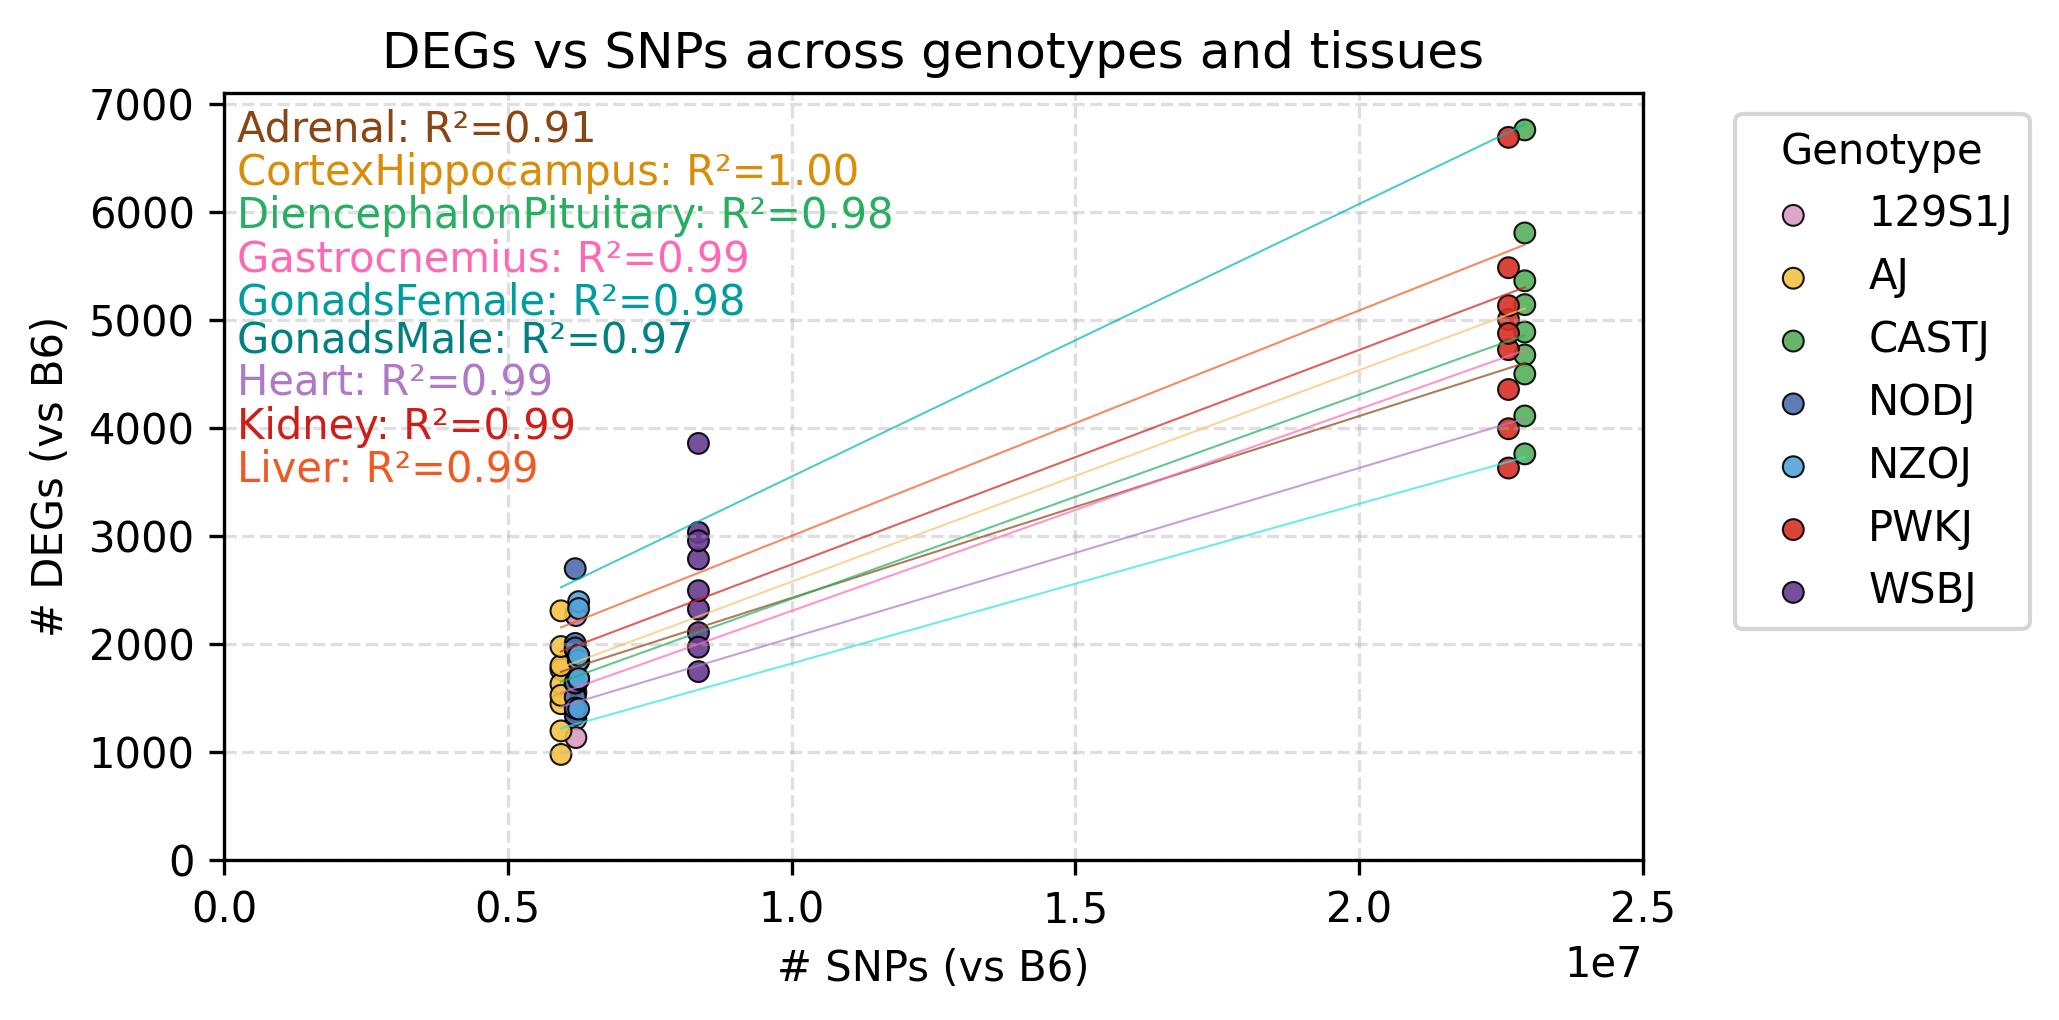

In [3]:
# Base plot
plt.figure(figsize=(7, 3.5), dpi=300)

# Scatter all points colored by genotype
for geno in deg_data["genotype"].unique():
    sub = deg_data[deg_data["genotype"] == geno]
    plt.scatter(
        sub["SNPs"],
        sub["DEGs"],
        label=geno,
        color=sub["color"],
        edgecolor="k",
        linewidth=0.5,
        alpha=0.9,
        s=25
    )

# Add regression line per tissue
for i, tissue in enumerate(deg_data["tissue"].unique()):
    sub = deg_data[deg_data["tissue"] == tissue]
    x = sub["SNPs"]
    y = sub["DEGs"]

    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2 = r_value**2

    # Plot regression line
    x_vals = np.linspace(x.min(), x.max(), 100)
    y_vals = slope * x_vals + intercept
    plt.plot(x_vals, y_vals, color=tissue_dict[tissue], linewidth=0.5, alpha=0.7)

    # Add R² text
    plt.text(
        x=0.01 * plt.xlim()[1],  # small x offset
        y=plt.ylim()[1] - (i + 1) * 400,  # stagger vertically
        s=f"{tissue}: R²={r2:.2f}",
        fontsize=10,
        color=tissue_dict_label[tissue]
    )

# Final touches
plt.xlabel("# SNPs (vs B6)")
plt.ylabel("# DEGs (vs B6)")
plt.ylim(0, None)
plt.xlim(0, 25000000)
plt.title("DEGs vs SNPs across genotypes and tissues")
plt.legend(title="Genotype", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# Fig. S4c

Tissue-specific DEGs

In [10]:
import pandas as pd
from collections import defaultdict

# Load DEGs data
geno_degs = pd.read_csv('/share/crsp/lab/seyedam/share/igvf_pipeline/figures/specificity/sig_degs_all_tissues_b6j_tissue_level.csv', index_col=0)

# Flip LFC signs so up/down are relative to non-B6J
geno_degs['log2FoldChange'] = -geno_degs['log2FoldChange'] 

# Define genotypes and tissues
genos = ['AJ', '129S1J', 'NODJ', 'NZOJ', 'CASTJ', 'PWKJ', 'WSBJ']
tissues = ['Heart','Liver','Adrenal','Gastrocnemius','Kidney',
           'CortexHippocampus','DiencephalonPituitary','GonadsMale','GonadsFemale']

# Storage for results
results = []

for geno in genos:
    geno_degs_subset = geno_degs[geno_degs['genotype'] == geno]

    # Separate upregulated and downregulated genes
    upregulated = geno_degs_subset[geno_degs_subset['log2FoldChange'] > 0]
    downregulated = geno_degs_subset[geno_degs_subset['log2FoldChange'] < 0]

    for condition, degs in zip(['Upregulated', 'Downregulated'], [upregulated, downregulated]):
        merged_df_filt_degs = degs[['gene_name', 'tissue']].drop_duplicates()

        # Create tissue-gene sets
        tissue_gene_sets = defaultdict(set)
        for _, row in merged_df_filt_degs.iterrows():
            tissue_gene_sets[row['tissue']].add(row['gene_name'])

        all_genes = set(merged_df_filt_degs['gene_name'])
        binary_matrix = {tissue: [gene in genes for gene in all_genes] for tissue, genes in tissue_gene_sets.items()}
        upset_df = pd.DataFrame(binary_matrix, index=list(all_genes))

        # Compute tissue-specific up/down genes
        for tiss in tissues:
            tiss_specific_genes = upset_df[(upset_df[tiss]) & (upset_df.drop(columns=[tiss]) == False).all(axis=1)]
            num_tiss_specific = len(tiss_specific_genes)

            # Total up/down genes in this genotype
            total_degs = len(all_genes)

            # Compute percentage
            percent_tiss_specific = (num_tiss_specific / total_degs) * 100 if total_degs > 0 else 0

            # Store result
            results.append([geno, condition, tiss, num_tiss_specific, percent_tiss_specific])

        # Compute shared across all tissues
        shared_all_tissues = upset_df[(upset_df[tissues].sum(axis=1) == len(tissues))]
        num_shared_all = len(shared_all_tissues)
        percent_shared_all = (num_shared_all / total_degs) * 100 if total_degs > 0 else 0
        results.append([geno, condition, 'All', num_shared_all, percent_shared_all])

        # Compute shared across some (2+ but not all) tissues
        shared_some_tissues = upset_df[(upset_df[tissues].sum(axis=1) > 1) & (upset_df[tissues].sum(axis=1) < len(tissues))]
        num_shared_some = len(shared_some_tissues)
        percent_shared_some = (num_shared_some / total_degs) * 100 if total_degs > 0 else 0
        results.append([geno, condition, 'Some', num_shared_some, percent_shared_some])




In [11]:
# Convert to DataFrame
summary_df = pd.DataFrame(results, columns=['Genotype', 'Condition', 'Tissue', 'n_genes', 'Percentage'])

summary_df = summary_df[summary_df['Tissue'] != 'Some']
summary_df = summary_df[summary_df['Tissue'] != 'All']

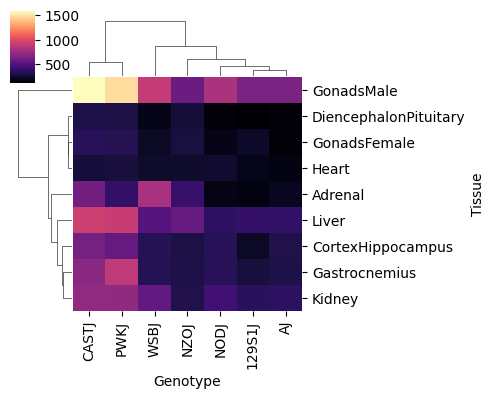

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for upregulated genes only
upregulated_df = summary_df[summary_df['Condition'] == 'Upregulated']

# Pivot the DataFrame: Tissue (rows) x Genotype (columns)
heatmap_data = upregulated_df.pivot(index='Tissue', columns='Genotype', values='n_genes')

# Create the clustermap
sns.clustermap(
    heatmap_data,
    cmap='magma',  # Red color gradient
    figsize=(5, 4)
)

plt.savefig(f"../supp_fig4/geno_specific_tissue_specific_gene_hmap_all_tissues_pbulk_sample_tissue_level.png", dpi=300, bbox_inches="tight")  
plt.show()


In [6]:
summary_df.head()

,Genotype,Condition,Tissue,n_genes,Percentage
0,AJ,Upregulated,Heart,168,4.411765
1,AJ,Upregulated,Liver,384,10.084034
2,AJ,Upregulated,Adrenal,212,5.567227
3,AJ,Upregulated,Gastrocnemius,315,8.272059
4,AJ,Upregulated,Kidney,367,9.637605


# Fig. S4d-e

## GO terms in tissue-specific genes 

In [13]:
import gseapy as gp
import numpy as np
import matplotlib.pyplot as plt
import textwrap



## Upregulated

168
384
212


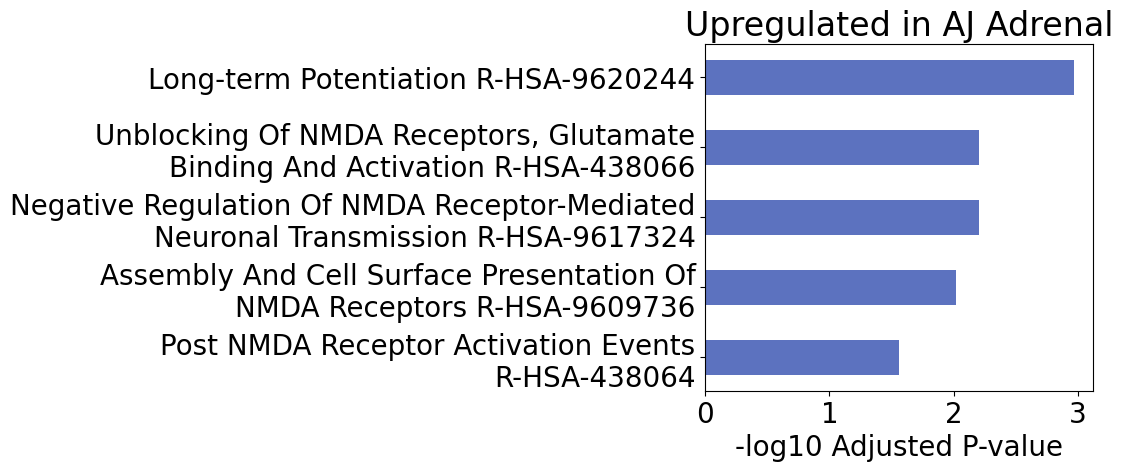

315
367
316
147
642
149
192


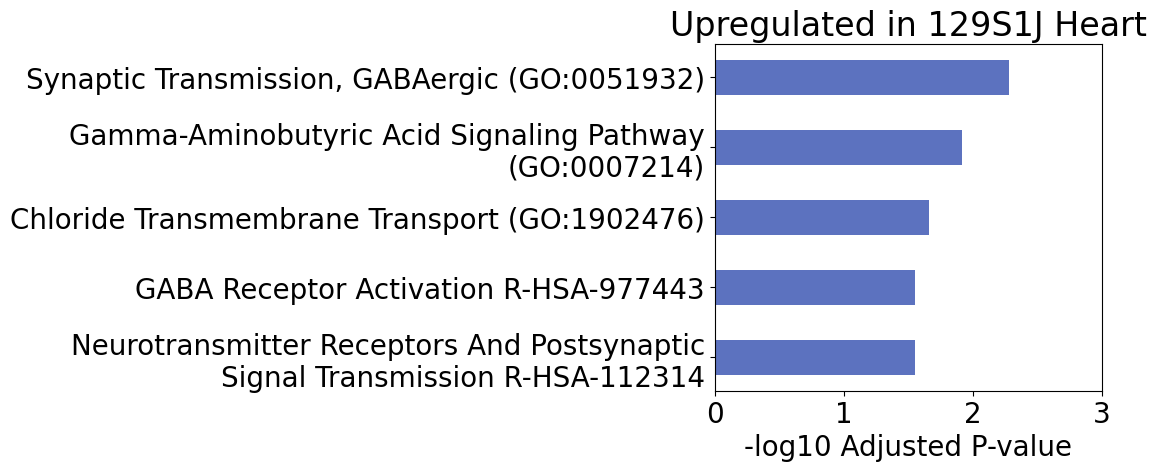

393
167
282
360
223
122
638
233
251


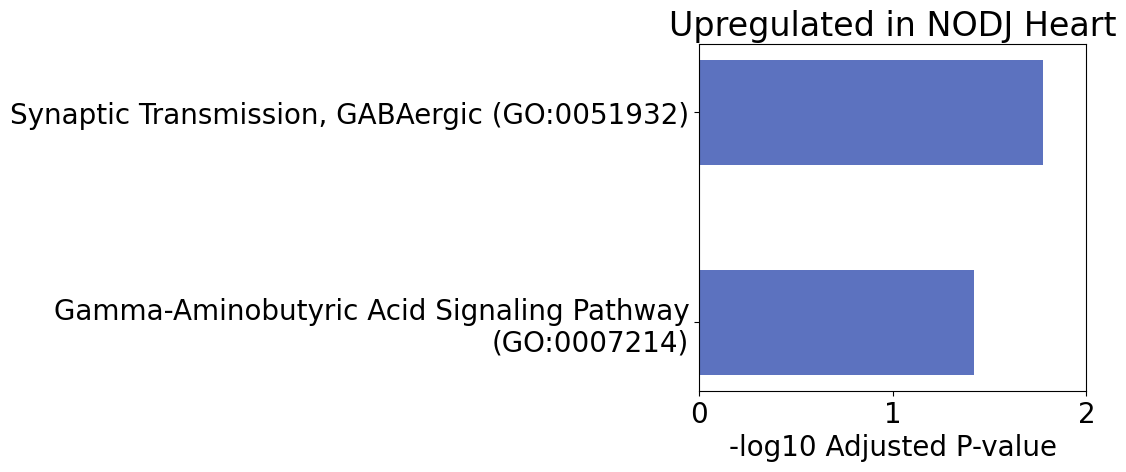

374
176
347
439
349
146
806
189
237


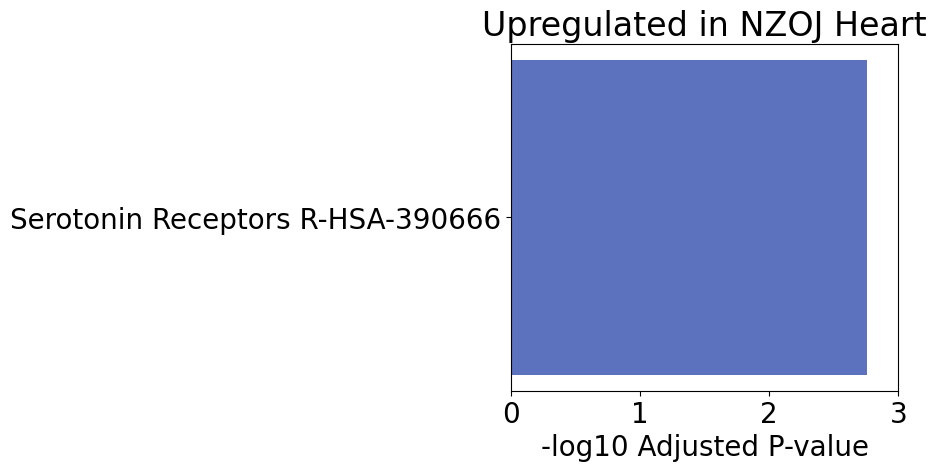

571
405


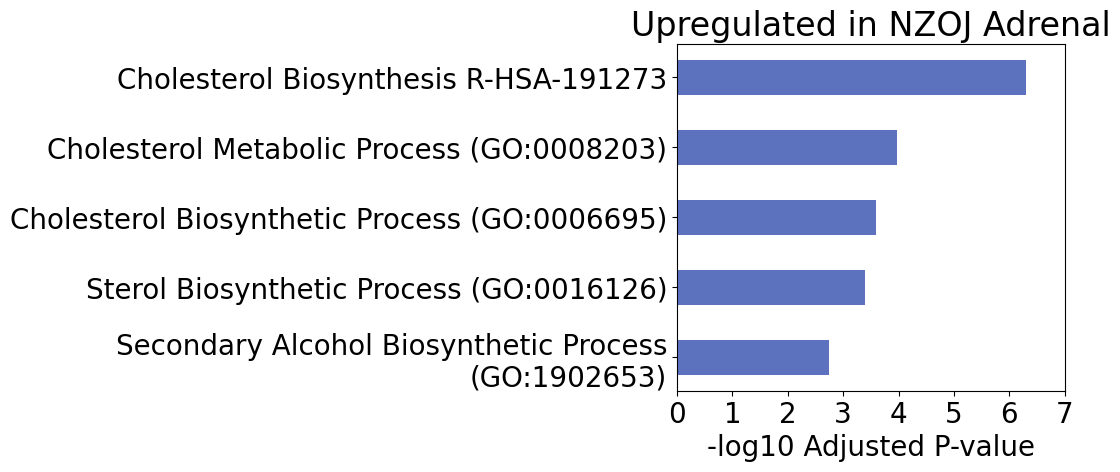

315
321
300
271


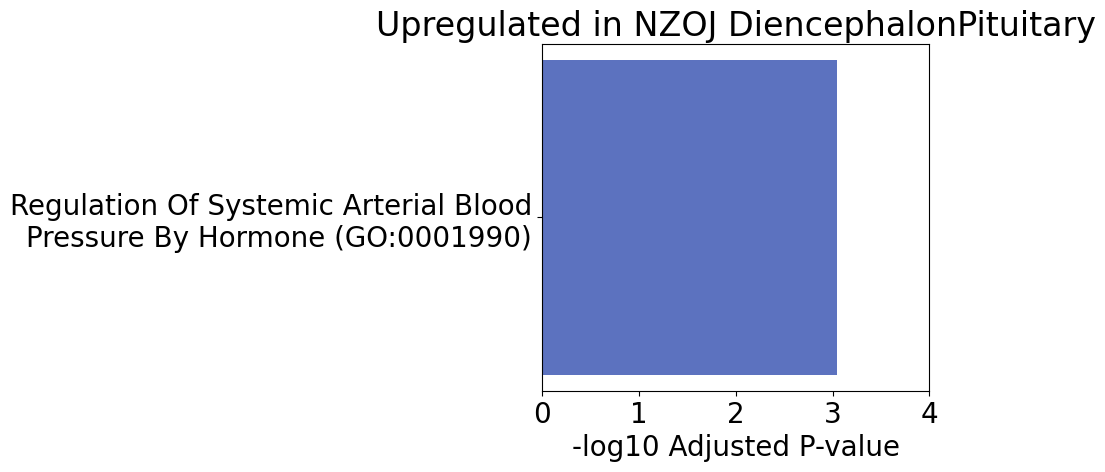

581
289
280
929
608
695
720
622
315
1578
354
286


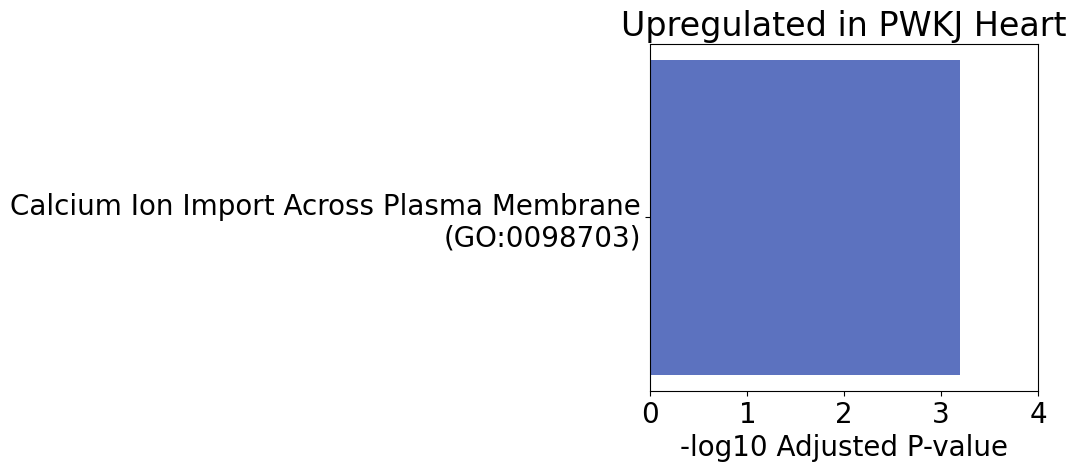

912
389
884
715
565
303
1474
334
241
501
801


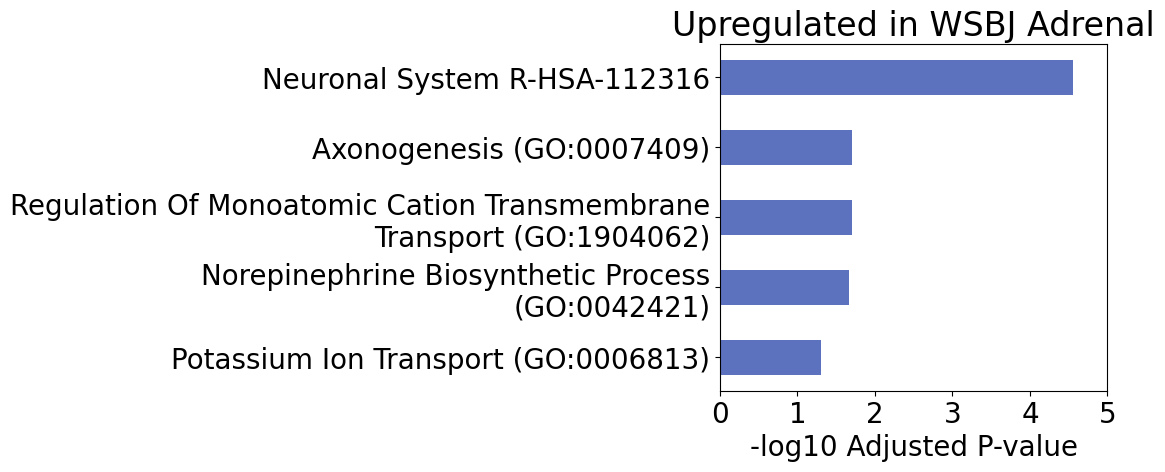

343
553
341
189
901
220


In [14]:
geno_degs = pd.read_csv('/share/crsp/lab/seyedam/share/igvf_pipeline/figures/specificity/sig_degs_all_tissues_b6j_tissue_level.csv', index_col = 0)
geno_degs =geno_degs[geno_degs['log2FoldChange'] < 0]


for geno in genos:
#geno = 'CASTJ'

    geno_degs_my_geno = geno_degs[geno_degs['genotype'] == geno]

    merged_df_filt_degs = geno_degs_my_geno[['gene_name', 'tissue']].drop_duplicates()

    tissue_gene_sets = defaultdict(set)
    for _, row in merged_df_filt_degs.iterrows():
        tissue_gene_sets[row['tissue']].add(row['gene_name'])


    all_genes = set(merged_df_filt_degs['gene_name'])
    binary_matrix = {tissue: [gene in genes for gene in all_genes] for tissue, genes in tissue_gene_sets.items()}
    upset_df = pd.DataFrame(binary_matrix, index=list(all_genes))

    for tiss in tissues:

        #tiss = 'Kidney'
        tiss_specific_genes = upset_df[(upset_df[tiss]) & (upset_df.drop(columns=[tiss]) == False).all(axis=1)]
        tiss_specific_genes = tiss_specific_genes.index.tolist()
        print(len(tiss_specific_genes))

        enr = gp.enrichr(
            gene_list=tiss_specific_genes,
            organism='Mouse', 
            gene_sets=['Reactome_2022', 'GO_Biological_Process_2023']
        )
        df = enr.results
        df = df.sort_values(by="Adjusted P-value", ascending=True)

        df['-log10(Adjusted P-value)'] = -np.log10(df['Adjusted P-value'])
        df = df[df['Adjusted P-value'] <= 0.05]
        df = df.head()

        import textwrap
        
        if not df.empty:
            # Wrap long GO terms
            df['Term_wrapped'] = df['Term'].apply(lambda x: '\n'.join(textwrap.wrap(x, width=45)))
        
            # Plot
            plt.figure(figsize=(5, 4.5))
            plt.barh(df['Term_wrapped'], df['-log10(Adjusted P-value)'], color='#5C72BF', height=0.5)
            plt.xlabel('-log10 Adjusted P-value', fontsize=20)
            plt.ylabel('')
            plt.title(f'Upregulated in {geno} {tiss}', fontsize=24)
            plt.gca().invert_yaxis()
        
            plt.xticks(np.arange(0, df['-log10(Adjusted P-value)'].max() + 1, 1))
            plt.yticks(fontsize=20)
            plt.xticks(fontsize=20)
        
            plt.savefig(f"../supp_fig4/degs_up_tiss_specific_goterms_{geno}_{tiss}.png", dpi=300, bbox_inches="tight")
        
            plt.show()


## Downregulated

174
612
319
359
307


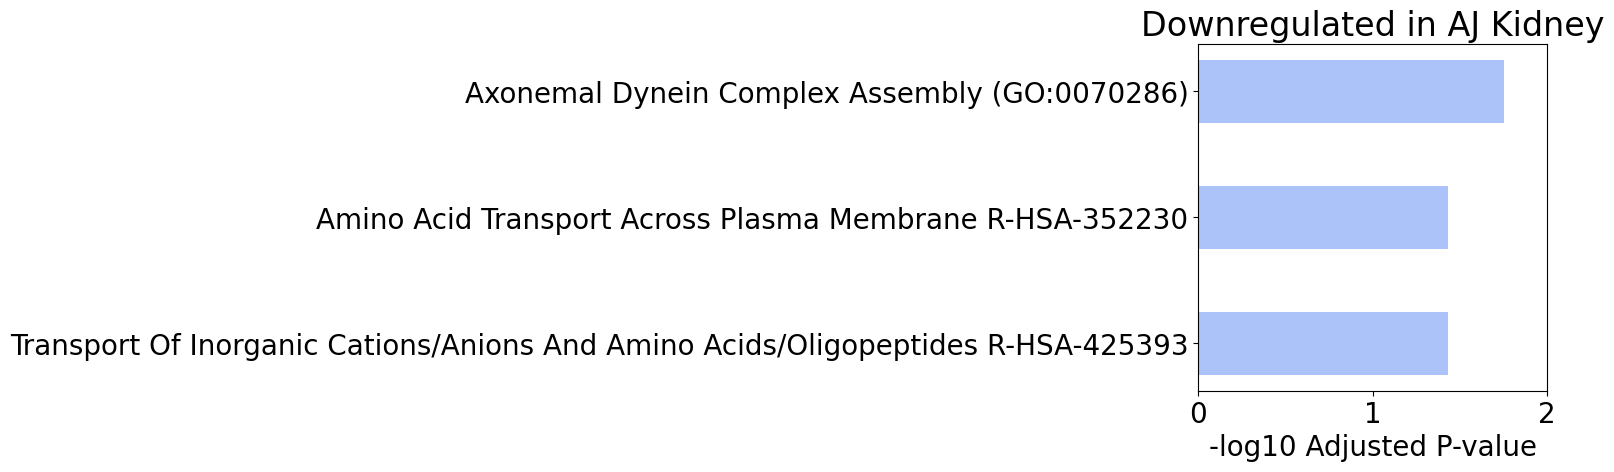

196
255


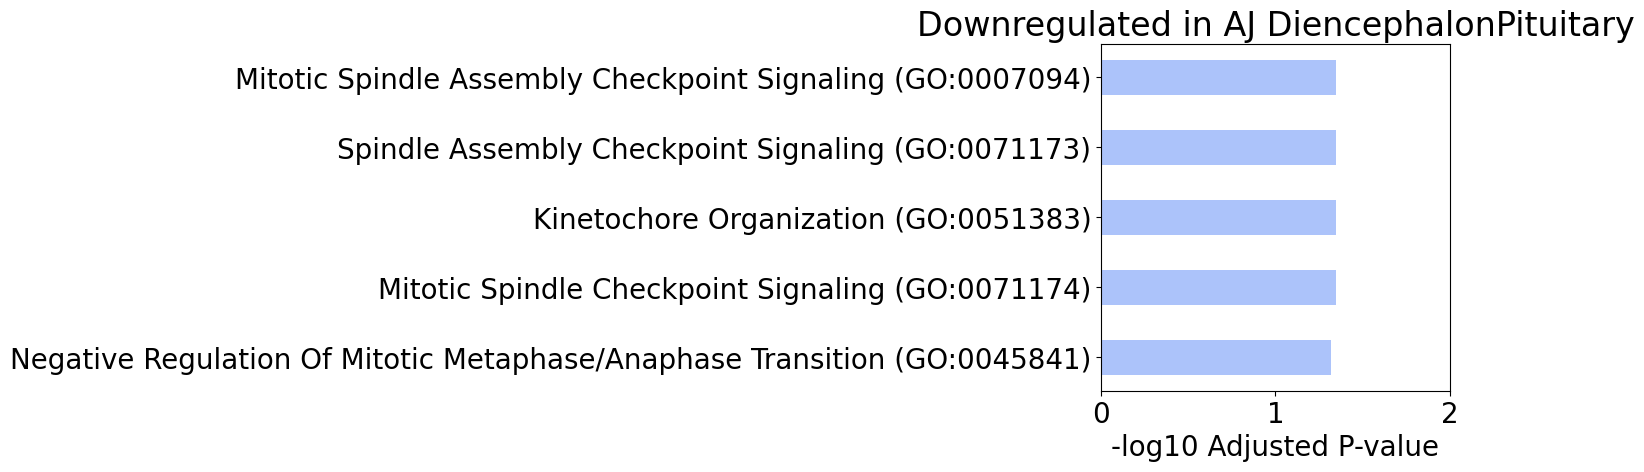

817
150
187
733


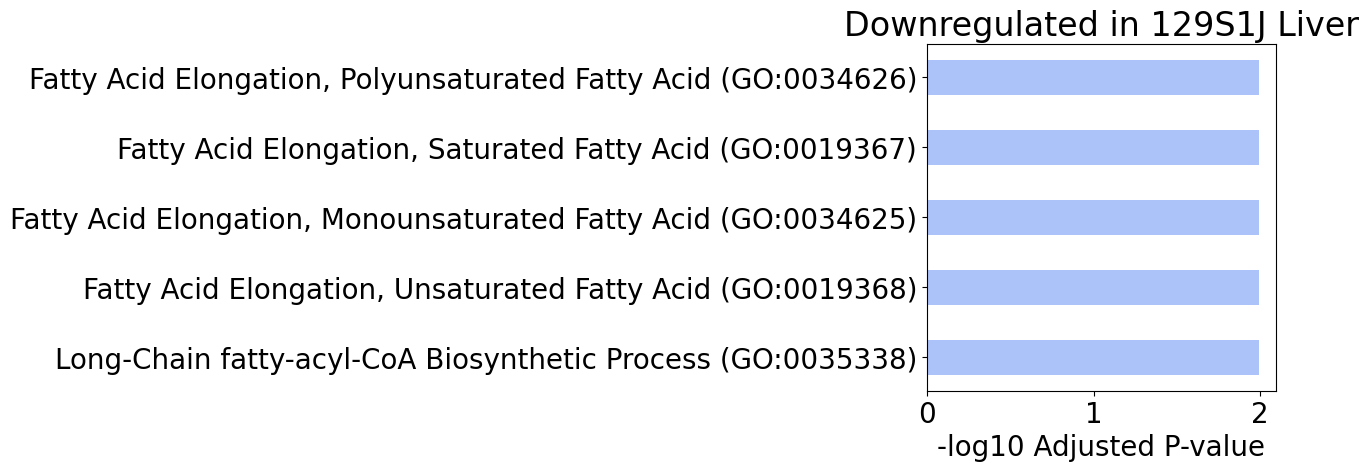

352


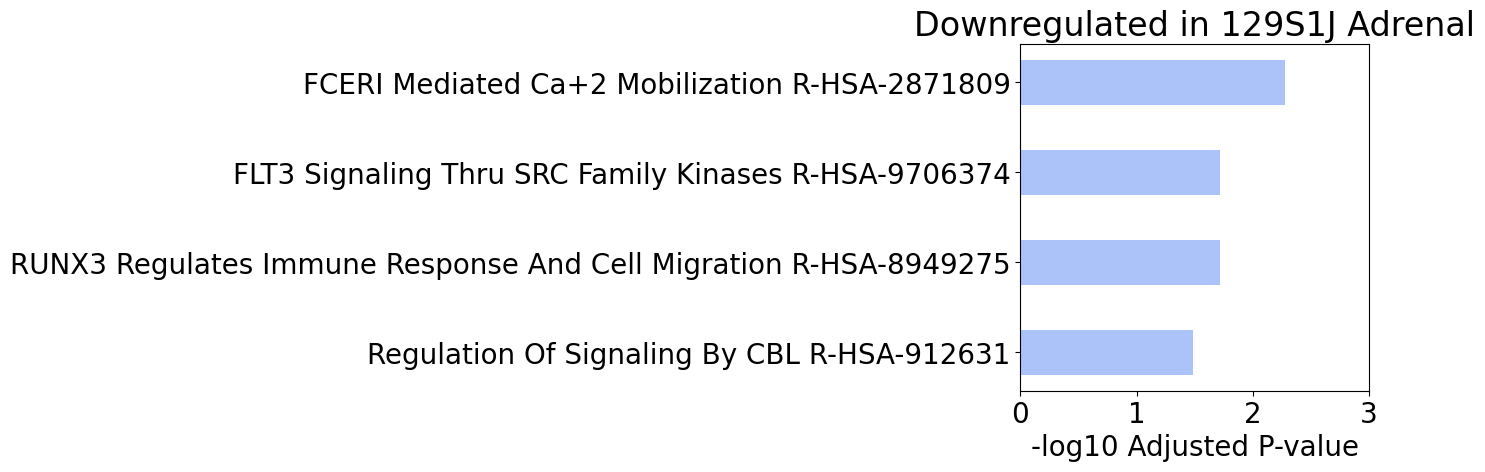

259
292
195
91
734
111
138
500
257


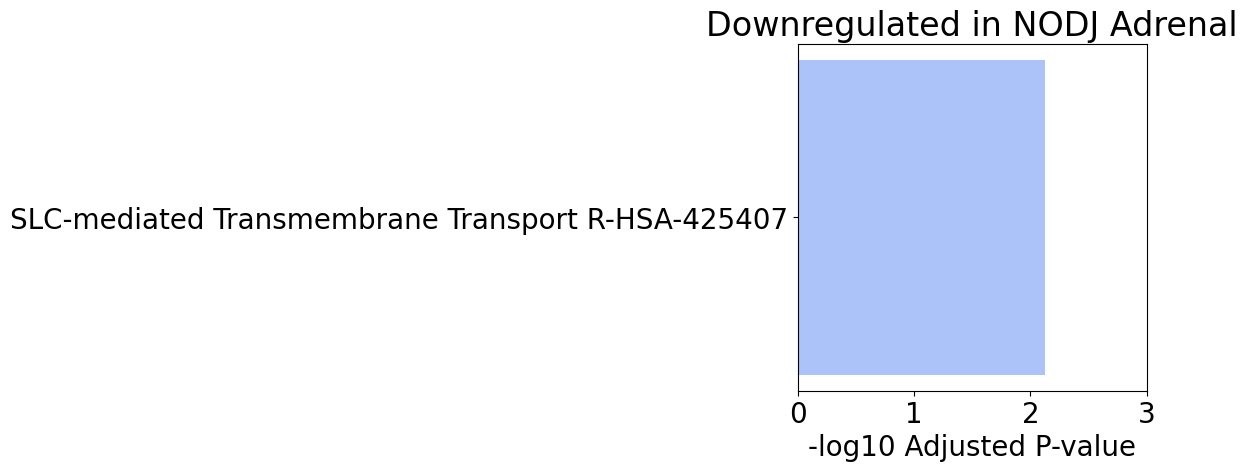

362
225
215
179
903
285
290
610
279
354
316
203
218
860
240
443
1095
506
589
580
362
468
1982
500
390
947
605
689
541
364
408
2103
428
276
803


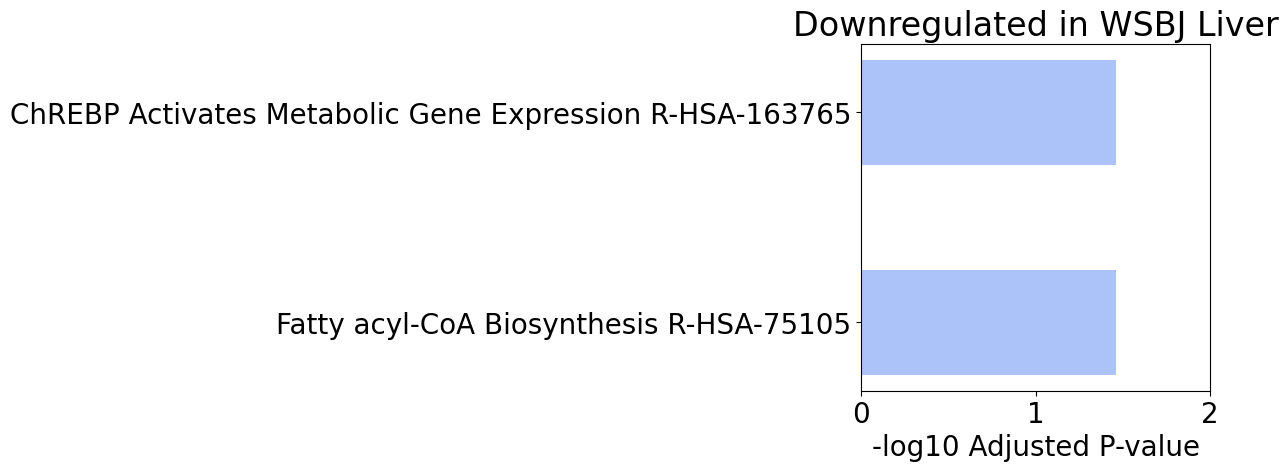

417
371
402
237
397
1484
307


In [27]:
geno_degs = pd.read_csv('/share/crsp/lab/seyedam/share/igvf_pipeline/figures/specificity/sig_degs_all_tissues_b6j_tissue_level.csv', index_col = 0)
geno_degs =geno_degs[geno_degs['log2FoldChange'] > 0]


for geno in genos:
#geno = 'CASTJ'

    geno_degs_my_geno = geno_degs[geno_degs['genotype'] == geno]

    merged_df_filt_degs = geno_degs_my_geno[['gene_name', 'tissue']].drop_duplicates()

    tissue_gene_sets = defaultdict(set)
    for _, row in merged_df_filt_degs.iterrows():
        tissue_gene_sets[row['tissue']].add(row['gene_name'])


    all_genes = set(merged_df_filt_degs['gene_name'])
    binary_matrix = {tissue: [gene in genes for gene in all_genes] for tissue, genes in tissue_gene_sets.items()}
    upset_df = pd.DataFrame(binary_matrix, index=list(all_genes))

    for tiss in tissues:

        #tiss = 'Kidney'
        tiss_specific_genes = upset_df[(upset_df[tiss]) & (upset_df.drop(columns=[tiss]) == False).all(axis=1)]
        tiss_specific_genes = tiss_specific_genes.index.tolist()
        print(len(tiss_specific_genes))

        enr = gp.enrichr(
            gene_list=tiss_specific_genes,
            organism='Mouse', 
            gene_sets=['Reactome_2022', 'GO_Biological_Process_2023']
        )
        df = enr.results
        df = df.sort_values(by="Adjusted P-value", ascending=True)

        df['-log10(Adjusted P-value)'] = -np.log10(df['Adjusted P-value'])
        df = df[df['Adjusted P-value'] <= 0.05]
        df = df.head()

        if not df.empty:

            # Plot
            plt.figure(figsize=(4.5, 4.5))
            plt.barh(df['Term'], df['-log10(Adjusted P-value)'], color='#ACC3FA', height = 0.5)
            plt.xlabel('-log10 Adjusted P-value', fontsize=20)
            plt.ylabel('')
            plt.title(f'Downregulated in {geno} {tiss}', fontsize = 24)
            plt.gca().invert_yaxis() 

            plt.xticks(np.arange(0, df['-log10(Adjusted P-value)'].max() + 1, 1))
            plt.yticks(fontsize=20) 
            plt.xticks(fontsize=20)

            plt.savefig(f"../supp_fig4/degs_down_tiss_specific_goterms_{geno}_{tiss}.png", dpi=300, bbox_inches="tight")  


            plt.show()